# Daniyal Khan || 221A061 || 19

In [ ]:
# Daniyal Khan || 221A061
!pip install yt-dlp pandas matplotlib textblob wordcloud


In [4]:
# Daniyal Khan || 221A061
import yt_dlp
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from wordcloud import WordCloud


In [5]:
# Daniyal Khan || 221A061

url_1 = "https://www.youtube.com/watch?v=RGKi6LSPDLU"  # Competitor 1
url_2 = "https://www.youtube.com/watch?v=Xe8CkYZvCig"  # Competitor 2


In [6]:
# Daniyal Khan || 221A061
def get_video_comments(url):
    ydl_opts = {
        'quiet': True,
        'extract_flat': False,
        'skip_download': True,
        'getcomments': True
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=False)

        comments = []
        if "comments" in info:
            for c in info["comments"]:
                if c and "text" in c:
                    comments.append(c["text"])

    return comments


In [7]:
# Daniyal Khan || 221A061
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"


In [10]:
# Daniyal Khan || 221A061
# Extract comments
comments1 = get_video_comments(url_1)
comments2 = get_video_comments(url_2)

# Create DataFrames
df1 = pd.DataFrame(comments1, columns=["Comment"])
df2 = pd.DataFrame(comments2, columns=["Comment"])

# Apply sentiment analysis
df1["Sentiment"] = df1["Comment"].apply(get_sentiment)
df2["Sentiment"] = df2["Comment"].apply(get_sentiment)


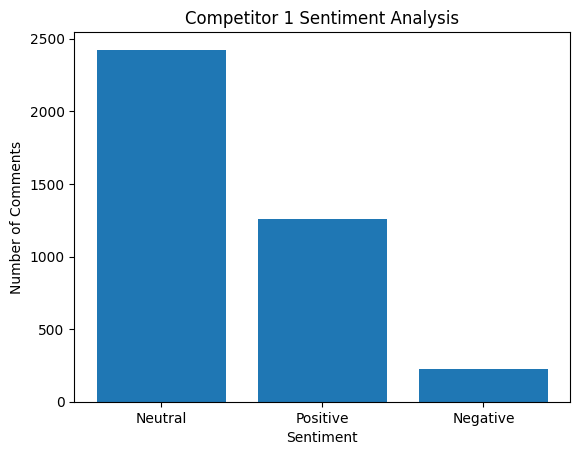

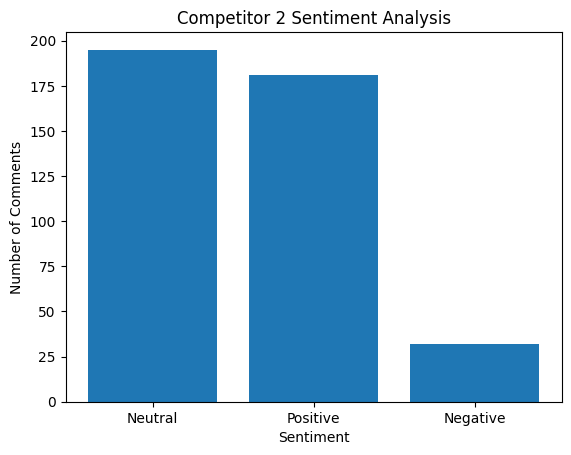

In [11]:
# Daniyal Khan || 221A061
sentiment1 = df1["Sentiment"].value_counts()
sentiment2 = df2["Sentiment"].value_counts()

plt.figure()
plt.bar(sentiment1.index, sentiment1.values)
plt.title("Competitor 1 Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

plt.figure()
plt.bar(sentiment2.index, sentiment2.values)
plt.title("Competitor 2 Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()


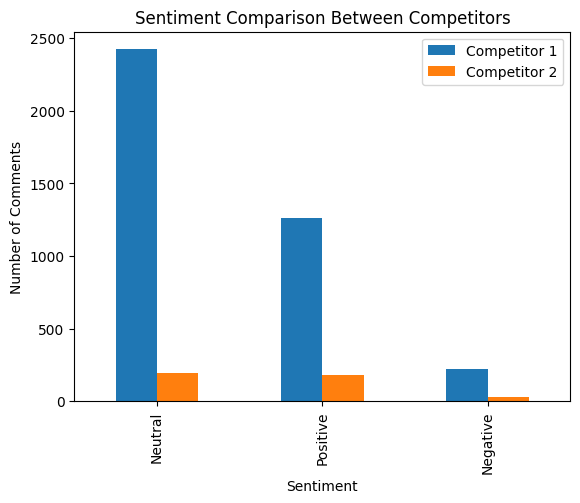

In [12]:
# Daniyal Khan || 221A061
comparison = pd.DataFrame({
    "Competitor 1": sentiment1,
    "Competitor 2": sentiment2
}).fillna(0)

comparison.plot(kind="bar")
plt.title("Sentiment Comparison Between Competitors")
plt.ylabel("Number of Comments")
plt.show()


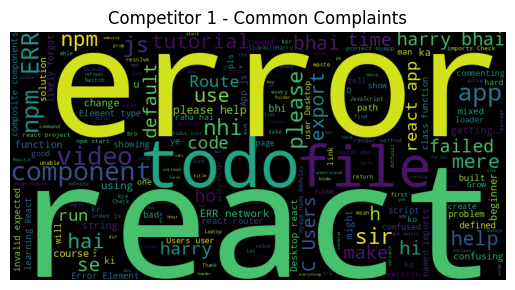

In [13]:
# Daniyal Khan || 221A061
neg1 = " ".join(df1[df1["Sentiment"]=="Negative"]["Comment"])
wc1 = WordCloud(width=800, height=400).generate(neg1)

plt.figure()
plt.imshow(wc1)
plt.axis("off")
plt.title("Competitor 1 - Common Complaints")
plt.show()


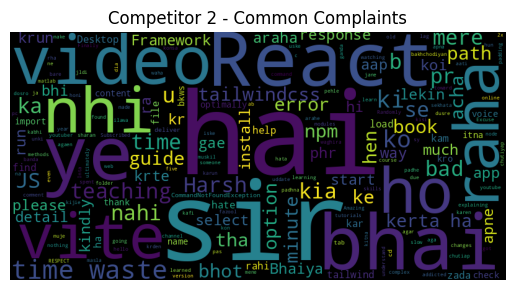

In [14]:
# Daniyal Khan || 221A061
neg2 = " ".join(df2[df2["Sentiment"]=="Negative"]["Comment"])
wc2 = WordCloud(width=800, height=400).generate(neg2)

plt.figure()
plt.imshow(wc2)
plt.axis("off")
plt.title("Competitor 2 - Common Complaints")
plt.show()


In [15]:
# Daniyal Khan || 221A061
import re
from collections import Counter


In [16]:
# Daniyal Khan || 221A061
stopwords = set([
    "the","is","and","to","of","in","it","for","on","this","that",
    "was","are","with","as","but","be","have","not","they","you",
    "a","an","at","by","from","or","we","so","if"
])


In [17]:
# Daniyal Khan || 221A061
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)  # Remove special characters
    words = text.split()
    words = [word for word in words if word not in stopwords and len(word) > 2]
    return words


In [18]:
# Daniyal Khan || 221A061
neg_comments1 = df1[df1["Sentiment"]=="Negative"]["Comment"]

all_words1 = []

for comment in neg_comments1:
    words = clean_text(comment)
    all_words1.extend(words)

freq1 = Counter(all_words1)

top_issues1 = freq1.most_common(10)

print("Top Improvement Areas - Competitor 1")
for word, count in top_issues1:
    print(word, ":", count)


Top Improvement Areas - Competitor 1
react : 63
error : 49
bhai : 31
please : 31
hai : 30
file : 29
its : 28
harry : 28
your : 28
err : 28


In [19]:
# Daniyal Khan || 221A061
neg_comments2 = df2[df2["Sentiment"]=="Negative"]["Comment"]

all_words2 = []

for comment in neg_comments2:
    words = clean_text(comment)
    all_words2.extend(words)

freq2 = Counter(all_words2)

top_issues2 = freq2.most_common(10)

print("\nTop Improvement Areas - Competitor 2")
for word, count in top_issues2:
    print(word, ":", count)



Top Improvement Areas - Competitor 2
hai : 12
sir : 11
time : 10
react : 7
bhai : 7
video : 7
nhi : 6
raha : 6
vite : 6
waste : 6


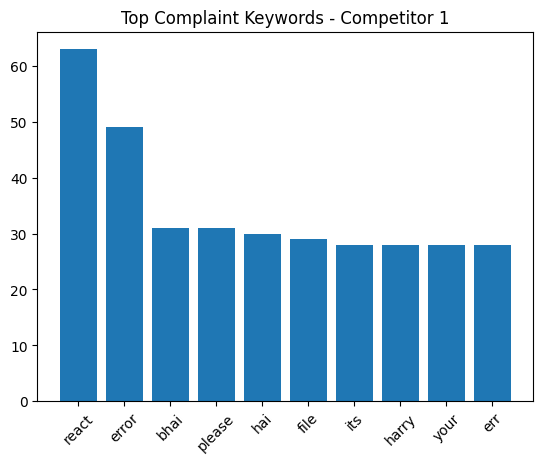

In [20]:
# Daniyal Khan || 221A061
words1 = [item[0] for item in top_issues1]
counts1 = [item[1] for item in top_issues1]

plt.figure()
plt.bar(words1, counts1)
plt.title("Top Complaint Keywords - Competitor 1")
plt.xticks(rotation=45)
plt.show()


In [21]:
# Daniyal Khan || 221A061
def satisfaction_score(df):
    total = len(df)
    positive = len(df[df["Sentiment"]=="Positive"])

    score = (positive / total) * 100
    return round(score,2)

score1 = satisfaction_score(df1)
score2 = satisfaction_score(df2)

print("Competitor 1 Satisfaction Score:", score1,"%")
print("Competitor 2 Satisfaction Score:", score2,"%")


Competitor 1 Satisfaction Score: 32.27 %
Competitor 2 Satisfaction Score: 44.36 %


In [ ]:
# Daniyal Khan || 221A061
!pip install nltk


In [23]:
# Daniyal Khan || 221A061
import nltk
from nltk.util import ngrams
from collections import Counter

nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [24]:
# Daniyal Khan || 221A061
def get_bigrams(text_series):
    all_bigrams = []

    for comment in text_series:
        words = clean_text(comment)
        bigrams = list(ngrams(words, 2))
        all_bigrams.extend(bigrams)

    return Counter(all_bigrams).most_common(10)


In [25]:
# Daniyal Khan || 221A061
print("Top Complaint Bigrams - Competitor 1")
print(get_bigrams(df1[df1["Sentiment"]=="Negative"]["Comment"]))

print("\nTop Complaint Bigrams - Competitor 2")
print(get_bigrams(df2[df2["Sentiment"]=="Negative"]["Comment"]))


Top Complaint Bigrams - Competitor 1
[(('harry', 'bhai'), 15), (('component', 'file'), 11), (('please', 'help'), 11), (('err', 'network'), 10), (('element', 'type'), 9), (('type', 'invalid'), 9), (('invalid', 'expected'), 9), (('expected', 'string'), 9), (('string', 'builtin'), 9), (('builtin', 'components'), 9)]

Top Complaint Bigrams - Competitor 2
[(('time', 'waste'), 6), (('raha', 'hai'), 4), (('framework', 'guides'), 2), (('hen', 'lekin'), 2), (('nhi', 'araha'), 2), (('waste', 'kerta'), 2), (('please', 'make'), 1), (('make', 'react'), 1), (('react', 'course'), 1), (('course', 'youtube'), 1)]


# Blog Analysis

In [ ]:
# Daniyal Khan || 221A061
!pip install requests beautifulsoup4 pandas matplotlib textblob wordcloud nltk


In [27]:
# Daniyal Khan || 221A061
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
from textblob import TextBlob
from wordcloud import WordCloud
import re
from collections import Counter
import nltk
from nltk.util import ngrams

nltk.download('punkt')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [28]:
# Daniyal Khan || 221A061

url_1 = "https://blog.logrocket.com/"
url_2 = "https://css-tricks.com/"


In [29]:
# Daniyal Khan || 221A061
def get_blog_content(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    paragraphs = soup.find_all("p")

    content = []
    for p in paragraphs:
        text = p.get_text().strip()
        if len(text) > 100:
            content.append(text)

    return content[:50]  # Limit for performance


In [30]:
# Daniyal Khan || 221A061
def get_sentiment(text):
    analysis = TextBlob(text)
    polarity = analysis.sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"


In [31]:
# Daniyal Khan || 221A061

content1 = get_blog_content(url_1)
content2 = get_blog_content(url_2)

df1 = pd.DataFrame(content1, columns=["Content"])
df2 = pd.DataFrame(content2, columns=["Content"])

df1["Sentiment"] = df1["Content"].apply(get_sentiment)
df2["Sentiment"] = df2["Content"].apply(get_sentiment)

df1.head()


,Content,Sentiment
0,Compare the top AI development tools and model...,Positive
1,Cut React LCP from 28s to ~1s with a four-phas...,Neutral
2,AI-first isn’t about tools; it’s about how tea...,Neutral
3,"Jemima Abu, a senior product engineer and awar...",Negative
4,Most design specs break down in development be...,Positive


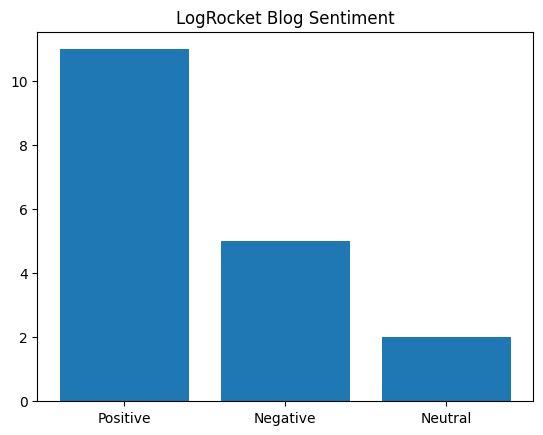

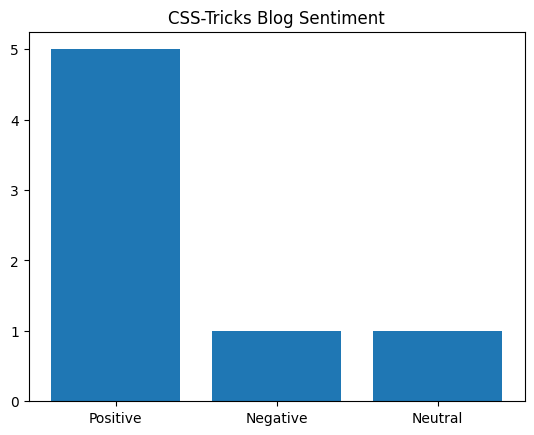

In [32]:
# Daniyal Khan || 221A061

sentiment1 = df1["Sentiment"].value_counts()
sentiment2 = df2["Sentiment"].value_counts()

plt.figure()
plt.bar(sentiment1.index, sentiment1.values)
plt.title("LogRocket Blog Sentiment")
plt.show()

plt.figure()
plt.bar(sentiment2.index, sentiment2.values)
plt.title("CSS-Tricks Blog Sentiment")
plt.show()


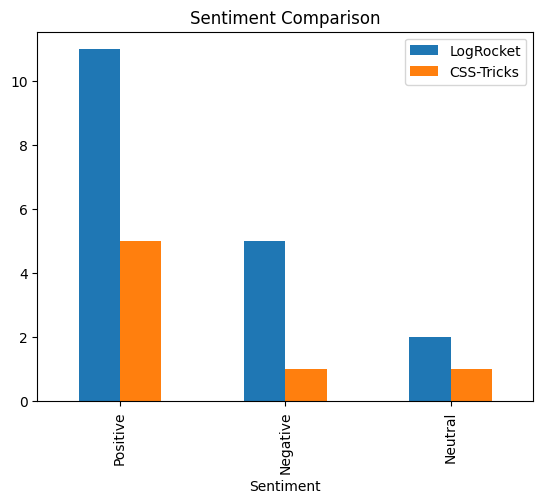

In [33]:
# Daniyal Khan || 221A061

comparison = pd.DataFrame({
    "LogRocket": sentiment1,
    "CSS-Tricks": sentiment2
}).fillna(0)

comparison.plot(kind="bar")
plt.title("Sentiment Comparison")
plt.show()


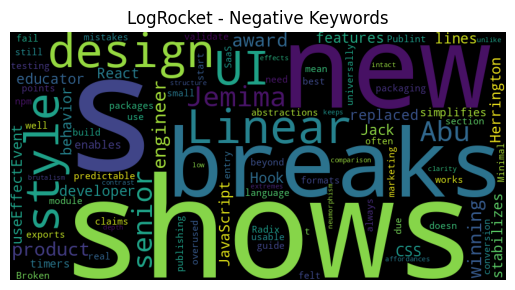

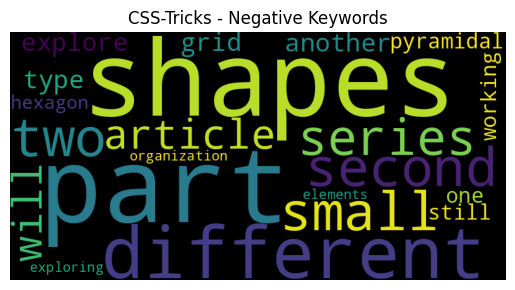

In [34]:
# Daniyal Khan || 221A061

neg1 = " ".join(df1[df1["Sentiment"]=="Negative"]["Content"])
wc1 = WordCloud(width=800, height=400).generate(neg1)

plt.figure()
plt.imshow(wc1)
plt.axis("off")
plt.title("LogRocket - Negative Keywords")
plt.show()

neg2 = " ".join(df2[df2["Sentiment"]=="Negative"]["Content"])
wc2 = WordCloud(width=800, height=400).generate(neg2)

plt.figure()
plt.imshow(wc2)
plt.axis("off")
plt.title("CSS-Tricks - Negative Keywords")
plt.show()


In [35]:
# Daniyal Khan || 221A061

stopwords = set([
    "the","is","and","to","of","in","it","for","on","this","that",
    "was","are","with","as","but","be","have","not","they","you",
    "a","an","at","by","from","or","we","so","if"
])


In [36]:
# Daniyal Khan || 221A061

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    words = text.split()
    words = [word for word in words if word not in stopwords and len(word) > 2]
    return words


In [37]:
# Daniyal Khan || 221A061

neg_content1 = df1[df1["Sentiment"]=="Negative"]["Content"]

all_words1 = []
for text in neg_content1:
    all_words1.extend(clean_text(text))

freq1 = Counter(all_words1)
top_issues1 = freq1.most_common(10)

print("Top Improvement Areas - LogRocket")
for word, count in top_issues1:
    print(word, ":", count)


Top Improvement Areas - LogRocket
how : 5
shows : 3
new : 2
breaks : 2
down : 2
design : 2
linearstyle : 2
why : 2
jemima : 1
abu : 1


In [38]:
# Daniyal Khan || 221A061

def satisfaction_score(df):
    total = len(df)
    positive = len(df[df["Sentiment"]=="Positive"])
    return round((positive / total) * 100, 2)

score1 = satisfaction_score(df1)
score2 = satisfaction_score(df2)

print("LogRocket Satisfaction Score:", score1,"%")
print("CSS-Tricks Satisfaction Score:", score2,"%")


LogRocket Satisfaction Score: 61.11 %
CSS-Tricks Satisfaction Score: 71.43 %


In [39]:
# Daniyal Khan || 221A061

def get_bigrams(text_series):
    all_bigrams = []
    for text in text_series:
        words = clean_text(text)
        bigrams = list(ngrams(words, 2))
        all_bigrams.extend(bigrams)
    return Counter(all_bigrams).most_common(10)

print("Top Complaint Bigrams - LogRocket")
print(get_bigrams(df1[df1["Sentiment"]=="Negative"]["Content"]))

print("\nTop Complaint Bigrams - CSS-Tricks")
print(get_bigrams(df2[df2["Sentiment"]=="Negative"]["Content"]))


Top Complaint Bigrams - LogRocket
[(('shows', 'how'), 3), (('breaks', 'down'), 2), (('jemima', 'abu'), 1), (('abu', 'senior'), 1), (('senior', 'product'), 1), (('product', 'engineer'), 1), (('engineer', 'awardwinning'), 1), (('awardwinning', 'developer'), 1), (('developer', 'educator'), 1), (('educator', 'shows'), 1)]

Top Complaint Bigrams - CSS-Tricks
[(('second', 'part'), 1), (('part', 'small'), 1), (('small', 'twopart'), 1), (('twopart', 'series'), 1), (('series', 'article'), 1), (('article', 'will'), 1), (('will', 'explore'), 1), (('explore', 'another'), 1), (('another', 'type'), 1), (('type', 'grid'), 1)]
